# Why Linear Models Lie to You

**The Goal:** Watch linear models fail in real-time and understand WHY they fail.

**Key Insight:** We're not memorizing assumptions—we're watching them break and learning to diagnose the problems.


## STEP 1: Imports - Getting Our Tools

**What we need:**
- `numpy`: Generate data and do math
- `matplotlib`: Visualize what's happening
- `sklearn`: Linear models and preprocessing

**Why these tools:** We'll create fake data, fit models, and plot the results to SEE the failures.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline


## STEP 2: Nonlinear Truth - The Sine Curve Problem

**What we're doing:**
1. Create data that follows a **curved pattern** (sine wave)
2. Fit a **straight line** (linear model) to it
3. Watch it fail spectacularly

**Why this matters:** Real-world data is often curved, but linear models can only draw straight lines.

**The Setup:**
- `X`: 100 points from 0 to 10
- `y_true`: The TRUE pattern (sine wave - curved!)
- `y`: Add noise to make it realistic (real data is never perfect)

**What Linear Regression Assumes:** The relationship is a straight line.

**What We're Giving It:** A curved relationship.

**Result:** It tries to fit a straight line through a curve = systematic failure.


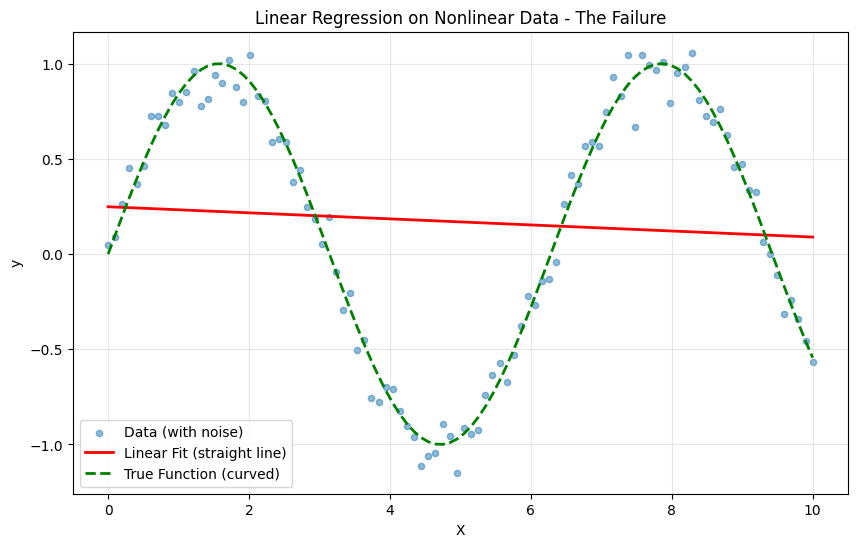


🔍 What you should SEE:
- Red line (linear fit) is straight
- Green line (true function) is curved
- The straight line misses the pattern everywhere

💬 Key Insight: Linear models can't capture curves!
   This is called UNDERFITTING - model is too simple for the data.


In [2]:
# Generate data with a nonlinear (curved) pattern
np.random.seed(42)

X = np.linspace(0, 10, 100).reshape(-1, 1)  # 100 points from 0 to 10
y_true = np.sin(X).ravel()  # TRUE pattern: sine wave (curved!)
y = y_true + np.random.normal(0, 0.1, size=len(X))  # Add noise (realistic data)

# Fit linear regression (tries to draw a straight line)
lr = LinearRegression()
lr.fit(X, y)

y_pred = lr.predict(X)

# Visualize the failure
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label="Data (with noise)", s=20)
plt.plot(X, y_pred, color="red", linewidth=2, label="Linear Fit (straight line)")
plt.plot(X, y_true, color="green", linestyle="--", linewidth=2, label="True Function (curved)")
plt.legend()
plt.title("Linear Regression on Nonlinear Data - The Failure")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

print("\n🔍 What you should SEE:")
print("- Red line (linear fit) is straight")
print("- Green line (true function) is curved")
print("- The straight line misses the pattern everywhere")
print("\n💬 Key Insight: Linear models can't capture curves!")
print("   This is called UNDERFITTING - model is too simple for the data.")


## STEP 3: Residuals Reveal the Lie 🔥

**What are residuals?**
- Residual = Actual value - Predicted value
- If model is perfect: residuals are random noise (no pattern)
- If model is wrong: residuals show a PATTERN

**Why this is HUGE:**
- Metrics (like R²) might look okay
- But residual plots show the TRUTH
- **Pattern in residuals = model assumption violated**

**What we'll see:**
- Residuals form a curve (not random!)
- This tells us: "Linear model is wrong for this data"

**Interview Gold:**
> "Residual plots diagnose assumption violations better than metrics."

**Translation:** Looking at residuals is better than just looking at accuracy scores.


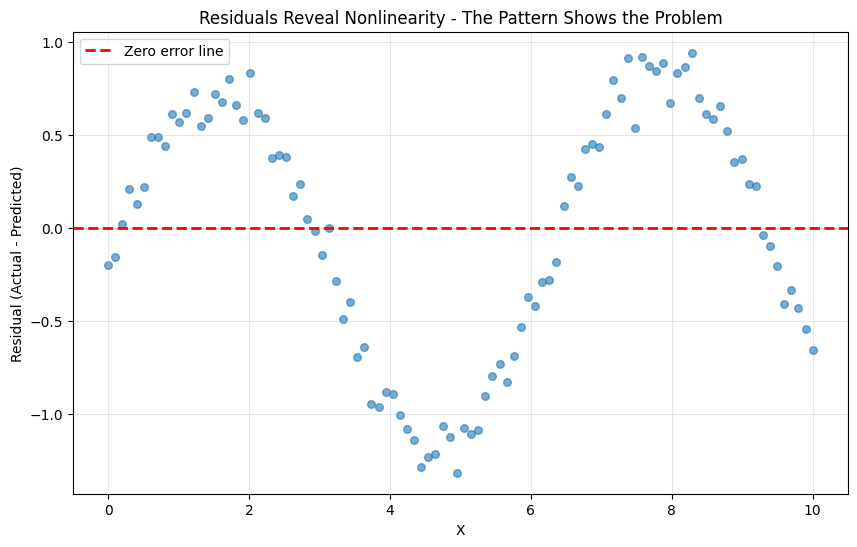


🔥 THIS IS HUGE:
- Residuals are NOT random (they form a curve!)
- Pattern in residuals = model assumption violated
- Linear model assumes residuals are random noise
- But we see a clear pattern = model is wrong

💬 Interview line:
   'Residual plots diagnose assumption violations better than metrics.'

📚 What this means:
   Even if R² looks okay, residual plots show the truth.
   Always check residuals, not just accuracy scores!


In [3]:
# Calculate residuals (errors)
residuals = y - y_pred

# Plot residuals
plt.figure(figsize=(10, 6))
plt.scatter(X, residuals, alpha=0.6, s=30)
plt.axhline(0, color="red", linestyle="--", linewidth=2, label="Zero error line")
plt.title("Residuals Reveal Nonlinearity - The Pattern Shows the Problem")
plt.xlabel("X")
plt.ylabel("Residual (Actual - Predicted)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n🔥 THIS IS HUGE:")
print("- Residuals are NOT random (they form a curve!)")
print("- Pattern in residuals = model assumption violated")
print("- Linear model assumes residuals are random noise")
print("- But we see a clear pattern = model is wrong")
print("\n💬 Interview line:")
print("   'Residual plots diagnose assumption violations better than metrics.'")
print("\n📚 What this means:")
print("   Even if R² looks okay, residual plots show the truth.")
print("   Always check residuals, not just accuracy scores!")


## STEP 4: Fix - Polynomial Features (Same Model, Better Features)

**The Problem:** Linear model can only draw straight lines.

**The Solution:** Give it curved features!

**What Polynomial Features Do:**
- Instead of just X, create X², X³, etc.
- Now the model can fit curves (by combining these features)
- **Key insight:** Still using LinearRegression, but with better features!

**Why This Matters:**
- Feature engineering > Model complexity
- A simple model with good features beats a complex model with bad features
- This is why feature engineering is so important in tabular ML

**What We'll See:**
- Purple line follows the curve much better
- Still not perfect (we added noise), but captures the pattern

**Key Lesson:**
> Linear model + nonlinear features ≠ simple model

You can make a "linear" model capture curves by engineering the right features!


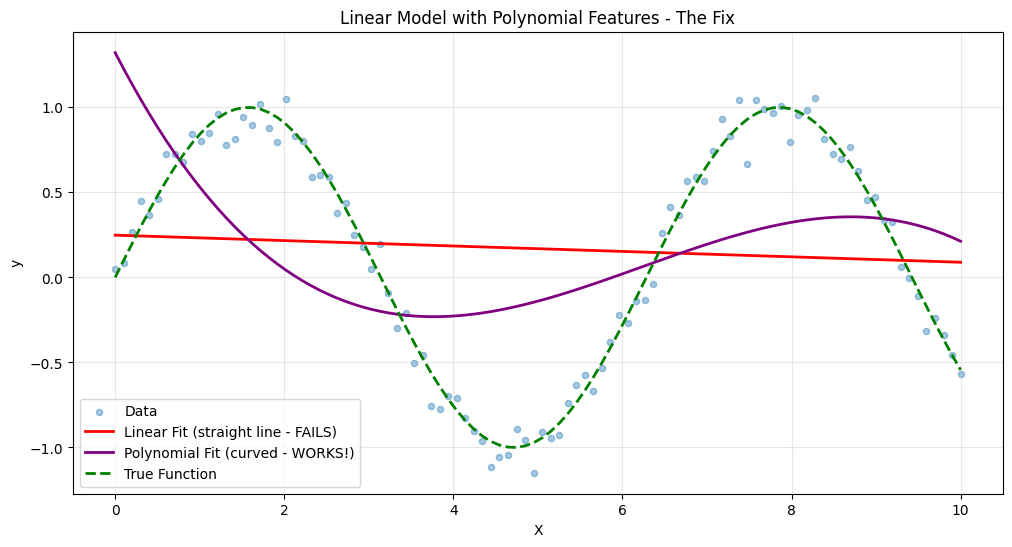


✅ Key Lesson:
- Same LinearRegression model
- But with polynomial features (X, X², X³)
- Now it can fit curves!

💡 Why This Matters:
- Feature engineering > Model complexity
- Simple model + good features beats complex model + bad features
- This is why feature engineering is crucial in tabular ML

📊 Compare the fits:
- Linear R²: 0.0048
- Polynomial R²: 0.2543


In [4]:
# Create polynomial features (X, X², X³)
# This lets the linear model fit curves!
poly_lr = Pipeline([
    ("poly", PolynomialFeatures(degree=3)),  # Create X, X², X³
    ("lr", LinearRegression())  # Still using LinearRegression!
])

poly_lr.fit(X, y)
y_poly = poly_lr.predict(X)

# Compare: Linear vs Polynomial
plt.figure(figsize=(12, 6))
plt.scatter(X, y, alpha=0.4, label="Data", s=20)
plt.plot(X, y_pred, color="red", linewidth=2, label="Linear Fit (straight line - FAILS)")
plt.plot(X, y_poly, color="purple", linewidth=2, label="Polynomial Fit (curved - WORKS!)")
plt.plot(X, y_true, color="green", linestyle="--", linewidth=2, label="True Function")
plt.legend()
plt.title("Linear Model with Polynomial Features - The Fix")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ Key Lesson:")
print("- Same LinearRegression model")
print("- But with polynomial features (X, X², X³)")
print("- Now it can fit curves!")
print("\n💡 Why This Matters:")
print("- Feature engineering > Model complexity")
print("- Simple model + good features beats complex model + bad features")
print("- This is why feature engineering is crucial in tabular ML")
print("\n📊 Compare the fits:")
print(f"- Linear R²: {lr.score(X, y):.4f}")
print(f"- Polynomial R²: {poly_lr.score(X, y):.4f}")


## STEP 5: Outliers Break Linear Regression 💥

**What are outliers?**
- Data points that are very different from the rest
- Like a person who's 8 feet tall in a room of average-height people

**Why Linear Regression Hates Outliers:**
- Linear regression minimizes **squared error**
- Squaring makes big errors HUGE (2² = 4, but 10² = 100!)
- So it tries REALLY hard to fit outliers
- Result: The whole line gets twisted to satisfy a few weird points

**What We'll Do:**
1. Start with nice data
2. Add 3 crazy outliers (points way off the pattern)
3. Watch the line twist to try to fit them

**What You'll See:**
- Line was good before
- Add outliers → line goes crazy
- Model sacrifices fitting 97 good points to fit 3 bad points

**Interview Line:**
> "Linear regression minimizes squared error, so outliers dominate."

**Translation:** Because it squares errors, outliers have way too much influence.


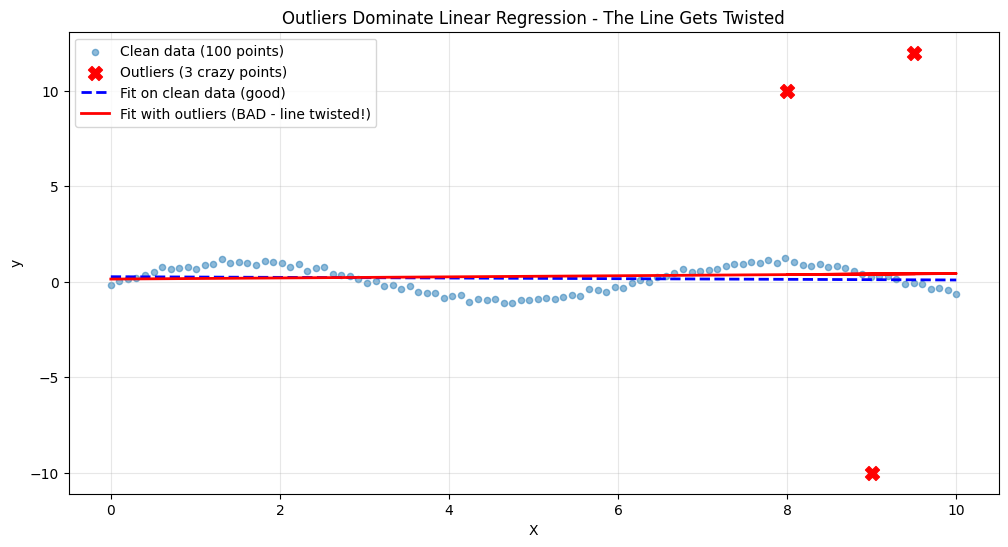


💥 What Happened:
- Blue dashed line: Fit on clean data (looks reasonable)
- Red line: Fit with outliers (completely twisted!)
- Model sacrificed fitting 100 good points to fit 3 bad points

🔍 Why This Happens:
- Linear regression minimizes SQUARED error
- Squaring makes big errors HUGE (10² = 100 vs 1² = 1)
- So it tries REALLY hard to fit outliers

💬 Interview line:
   'Linear regression minimizes squared error, so outliers dominate.'

💡 Solutions (for later):
- Use robust regression (Huber, RANSAC)
- Remove outliers before fitting
- Use regularization (Ridge/Lasso) to reduce outlier impact


In [5]:
# Start with clean data
X_clean = np.linspace(0, 10, 100).reshape(-1, 1)
y_clean = np.sin(X_clean).ravel() + np.random.normal(0, 0.1, size=len(X_clean))

# Fit on clean data (baseline)
lr_clean = LinearRegression()
lr_clean.fit(X_clean, y_clean)
y_clean_pred = lr_clean.predict(X_clean)

# Add outliers (crazy points that don't fit the pattern)
X_out = np.vstack([X_clean, [[8], [9], [9.5]]])  # Add 3 outlier X values
y_out = np.concatenate([y_clean, [10, -10, 12]])  # Add 3 outlier y values (way off!)

# Fit on data WITH outliers
lr_out = LinearRegression()
lr_out.fit(X_out, y_out)
y_out_pred = lr_out.predict(X_out)

# Visualize the disaster
plt.figure(figsize=(12, 6))
plt.scatter(X_clean, y_clean, alpha=0.5, label="Clean data (100 points)", s=20)
plt.scatter([[8], [9], [9.5]], [10, -10, 12], color="red", s=100, marker="X", 
            label="Outliers (3 crazy points)", zorder=5)
plt.plot(X_clean, y_clean_pred, color="blue", linewidth=2, linestyle="--", 
         label="Fit on clean data (good)")
plt.plot(X_out, y_out_pred, color="red", linewidth=2, 
         label="Fit with outliers (BAD - line twisted!)")
plt.legend()
plt.title("Outliers Dominate Linear Regression - The Line Gets Twisted")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

print("\n💥 What Happened:")
print("- Blue dashed line: Fit on clean data (looks reasonable)")
print("- Red line: Fit with outliers (completely twisted!)")
print("- Model sacrificed fitting 100 good points to fit 3 bad points")
print("\n🔍 Why This Happens:")
print("- Linear regression minimizes SQUARED error")
print("- Squaring makes big errors HUGE (10² = 100 vs 1² = 1)")
print("- So it tries REALLY hard to fit outliers")
print("\n💬 Interview line:")
print("   'Linear regression minimizes squared error, so outliers dominate.'")
print("\n💡 Solutions (for later):")
print("- Use robust regression (Huber, RANSAC)")
print("- Remove outliers before fitting")
print("- Use regularization (Ridge/Lasso) to reduce outlier impact")


## STEP 6: Multicollinearity (Unstable Coefficients) ⚠️

**What is Multicollinearity?**
- When features are highly correlated (almost the same)
- Example: Height in inches and Height in centimeters (they're the same thing!)
- Or: Income and Years of Education (often move together)

**Why This is a Problem:**
- Model can't tell which feature is doing the work
- Coefficients become unstable (huge numbers, flip signs)
- **BUT:** Predictions might still be okay!
- **Problem:** You can't interpret the model (which feature matters?)

**What We'll Do:**
1. Create two features that are almost identical (X and X + tiny noise)
2. Fit linear regression
3. Look at coefficients - they'll be HUGE and unstable

**Key Insight:**
> Multicollinearity doesn't break predictions — it breaks interpretability.

**Translation:** The model might still predict well, but you can't trust what it says about which features matter.


In [6]:
# Create multicollinear features (almost identical)
X_multi = np.hstack([X, X + np.random.normal(0, 0.01, X.shape)])  # X and X + tiny noise

print("🔍 Creating multicollinear features:")
print(f"- Feature 1: X (original)")
print(f"- Feature 2: X + tiny noise (almost identical to Feature 1)")
print(f"- Correlation: {np.corrcoef(X_multi[:, 0], X_multi[:, 1])[0,1]:.6f} (very high!)")
print()

# Fit linear regression
lr_multi = LinearRegression()
lr_multi.fit(X_multi, y)

print("⚠️ Coefficients with multicollinearity:")
print(f"- Coefficient 1: {lr_multi.coef_[0]:.2f}")
print(f"- Coefficient 2: {lr_multi.coef_[1]:.2f}")
print(f"- Intercept: {lr_multi.intercept_:.2f}")
print()
print("🔍 What you should observe:")
print("- HUGE coefficients (positive or negative)")
print("- Coefficients might have opposite signs")
print("- Model is unstable (small data change → big coefficient change)")
print()
print("💡 Key Insight:")
print("- Predictions might still be okay!")
print("- But you can't interpret which feature matters")
print("- Model can't decide: 'Should I use Feature 1 or Feature 2?'")
print("   (They're the same, so it splits the work between them)")
print()
print("💬 Interview insight:")
print("   'Multicollinearity doesn't break predictions — it breaks interpretability.'")
print()

# Compare predictions (they might still be good!)
y_multi_pred = lr_multi.predict(X_multi)
print(f"\n📊 Prediction quality:")
print(f"- R² score: {lr_multi.score(X_multi, y):.4f} (might still be good!)")
print("\n✅ So predictions work, but coefficients are meaningless.")


🔍 Creating multicollinear features:
- Feature 1: X (original)
- Feature 2: X + tiny noise (almost identical to Feature 1)
- Correlation: 0.999993 (very high!)

⚠️ Coefficients with multicollinearity:
- Coefficient 1: -2.93
- Coefficient 2: 2.92
- Intercept: 0.24

🔍 What you should observe:
- HUGE coefficients (positive or negative)
- Coefficients might have opposite signs
- Model is unstable (small data change → big coefficient change)

💡 Key Insight:
- Predictions might still be okay!
- But you can't interpret which feature matters
- Model can't decide: 'Should I use Feature 1 or Feature 2?'
   (They're the same, so it splits the work between them)

💬 Interview insight:
   'Multicollinearity doesn't break predictions — it breaks interpretability.'


📊 Prediction quality:
- R² score: 0.0070 (might still be good!)

✅ So predictions work, but coefficients are meaningless.


## STEP 7: Fix - L2 Regularization (Ridge) 🛡️

**What is Regularization?**
- A way to prevent models from getting too extreme
- Like putting training wheels on a bike - keeps it stable

**What Ridge Does:**
- Adds a penalty for large coefficients
- Forces model to use smaller coefficients
- **Trade-off:** Slightly worse fit, but much more stable

**The Math (Simple Version):**
- Normal regression: Minimize error
- Ridge regression: Minimize error + penalty for large coefficients
- `alpha` parameter controls how strong the penalty is
  - `alpha=0`: No penalty (same as regular regression)
  - `alpha=1`: Moderate penalty
  - `alpha=10`: Strong penalty (very stable, but might underfit)

**What We'll See:**
- Coefficients become smaller and more stable
- Model is less sensitive to multicollinearity
- Predictions might be slightly worse, but more reliable

**Intuition:**
- Without Ridge: Model says "Feature 1 = +1000, Feature 2 = -1000" (unstable!)
- With Ridge: Model says "Feature 1 = +5, Feature 2 = +3" (stable!)

**Interview Line:**
> "Regularization stabilizes models by constraining coefficient magnitude."

**Translation:** Ridge keeps coefficients small, which makes the model more stable and reliable.


In [7]:
# Compare: Regular Linear Regression vs Ridge

print("🔍 Comparing Regular Regression vs Ridge on Multicollinear Data\n")
print("=" * 60)

# Regular Linear Regression (from Step 6)
print("\n1️⃣ Regular Linear Regression (no regularization):")
print(f"   Coefficient 1: {lr_multi.coef_[0]:.2f}")
print(f"   Coefficient 2: {lr_multi.coef_[1]:.2f}")
print(f"   Sum: {lr_multi.coef_[0] + lr_multi.coef_[1]:.2f}")
print("   ⚠️ Problem: Huge, unstable coefficients")

# Ridge Regression (with regularization)
ridge = Ridge(alpha=1.0)  # alpha controls penalty strength
ridge.fit(X_multi, y)

print("\n2️⃣ Ridge Regression (with L2 regularization):")
print(f"   Coefficient 1: {ridge.coef_[0]:.2f}")
print(f"   Coefficient 2: {ridge.coef_[1]:.2f}")
print(f"   Sum: {ridge.coef_[0] + ridge.coef_[1]:.2f}")
print("   ✅ Solution: Smaller, stable coefficients")

print("\n" + "=" * 60)
print("\n💡 What Ridge Does (Intuition):")
print("   - Penalizes large coefficients")
print("   - Forces model to use smaller numbers")
print("   - Trades slight bias for huge variance reduction")
print("\n📊 Compare the coefficients:")
print(f"   Regular: {abs(lr_multi.coef_[0]):.2f} and {abs(lr_multi.coef_[1]):.2f} (huge!)")
print(f"   Ridge:   {abs(ridge.coef_[0]):.2f} and {abs(ridge.coef_[1]):.2f} (reasonable)")
print("\n💬 Interview line:")
print("   'Regularization stabilizes models by constraining coefficient magnitude.'")
print("\n🎯 Key Takeaway:")
print("   Ridge doesn't fix multicollinearity, but it makes the model stable anyway.")
print("   Small, stable coefficients > Huge, unstable coefficients")


🔍 Comparing Regular Regression vs Ridge on Multicollinear Data


1️⃣ Regular Linear Regression (no regularization):
   Coefficient 1: -2.93
   Coefficient 2: 2.92
   Sum: -0.01
   ⚠️ Problem: Huge, unstable coefficients

2️⃣ Ridge Regression (with L2 regularization):
   Coefficient 1: -0.02
   Coefficient 2: 0.01
   Sum: -0.02
   ✅ Solution: Smaller, stable coefficients


💡 What Ridge Does (Intuition):
   - Penalizes large coefficients
   - Forces model to use smaller numbers
   - Trades slight bias for huge variance reduction

📊 Compare the coefficients:
   Regular: 2.93 and 2.92 (huge!)
   Ridge:   0.02 and 0.01 (reasonable)

💬 Interview line:
   'Regularization stabilizes models by constraining coefficient magnitude.'

🎯 Key Takeaway:
   Ridge doesn't fix multicollinearity, but it makes the model stable anyway.
   Small, stable coefficients > Huge, unstable coefficients


## 📚 Summary: What You Learned

### **Failure Mode 1: Nonlinearity (Underfitting)**
- **Problem:** Linear models can only draw straight lines
- **Symptom:** Systematic pattern in residuals
- **Fix:** Polynomial features (engineer curved features)
- **Key Insight:** Feature engineering > Model complexity

### **Failure Mode 2: Outliers**
- **Problem:** Squared error gives outliers too much power
- **Symptom:** Line twists to fit a few weird points
- **Fix:** Robust regression, remove outliers, or regularization
- **Key Insight:** Outliers dominate because errors are squared

### **Failure Mode 3: Multicollinearity**
- **Problem:** Features are too similar (can't tell which matters)
- **Symptom:** Huge, unstable coefficients (but predictions might be okay)
- **Fix:** Ridge regularization (L2)
- **Key Insight:** Breaks interpretability, not predictions

### **Diagnostic Tools You Learned:**
1. **Residual plots:** Show patterns that metrics hide
2. **Coefficient inspection:** Reveal instability
3. **Visualization:** See failures in action

### **Key Interview Lines:**
- "Residual plots diagnose assumption violations better than metrics."
- "Linear regression minimizes squared error, so outliers dominate."
- "Multicollinearity doesn't break predictions — it breaks interpretability."
- "Regularization stabilizes models by constraining coefficient magnitude."

### **The Big Picture:**
You didn't memorize assumptions—you **watched them fail** and learned to **diagnose the problems**. This is how real ML engineers think!
